DATA VISUALIZATION & DASHBOARD



In [11]:
import os

print("Python is currently running from:")
print(os.getcwd())

print("\nItems in this folder:")
print(os.listdir())

Python is currently running from:
c:\Users\Admin\OneDrive\Desktop\task3

Items in this folder:
['data', 'plots', 'README.md', 'requirements.txt', 'visualizatiion.py', 'visualization.ipynb']


In [12]:
import os

print("Is plots a folder?")
print(os.path.isdir("plots"))

print("Is plots a file?")
print(os.path.isfile("plots"))

Is plots a folder?
False
Is plots a file?
True


In [13]:
import os

print(os.path.abspath("data"))
print(os.path.abspath("plots"))

c:\Users\Admin\OneDrive\Desktop\task3\data
c:\Users\Admin\OneDrive\Desktop\task3\plots


In [6]:
import pandas as pd

df = pd.read_csv("data/processed_data.csv")

print(df.head())
print(df.info())


   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0            Set  ...      INR  647.

CREATE VISUALIZATIONS

LINE CHART


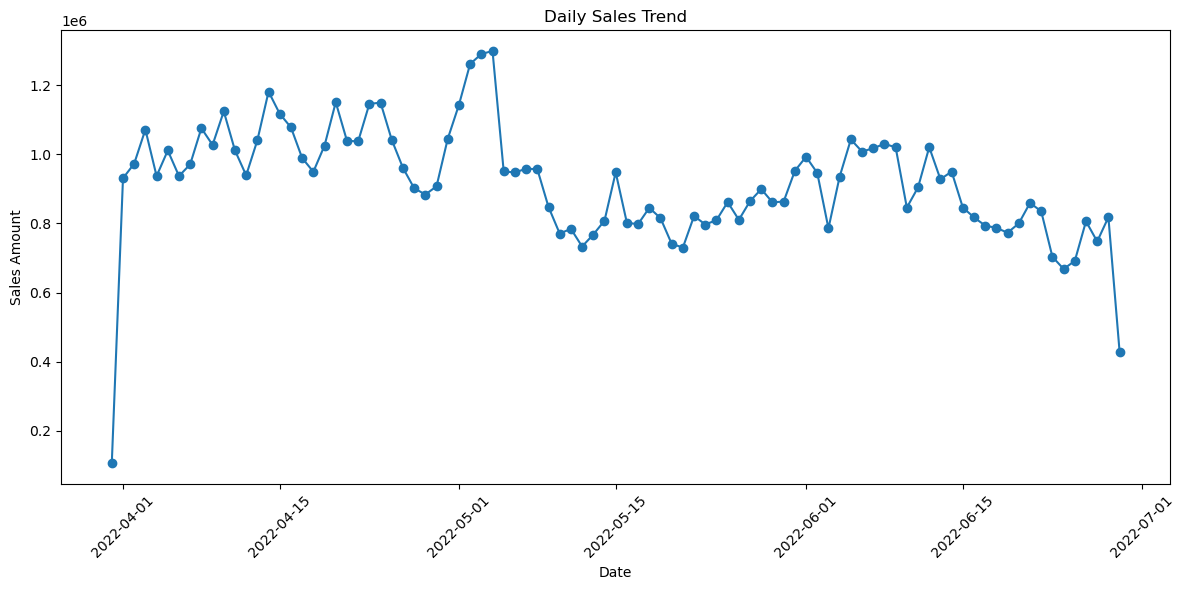

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Group sales by date
daily_sales = df.groupby("Date")["Amount"].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_sales.index, daily_sales.values, marker='o')

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales Amount")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("plots/line_chart.png")
plt.show()

BAR CHART


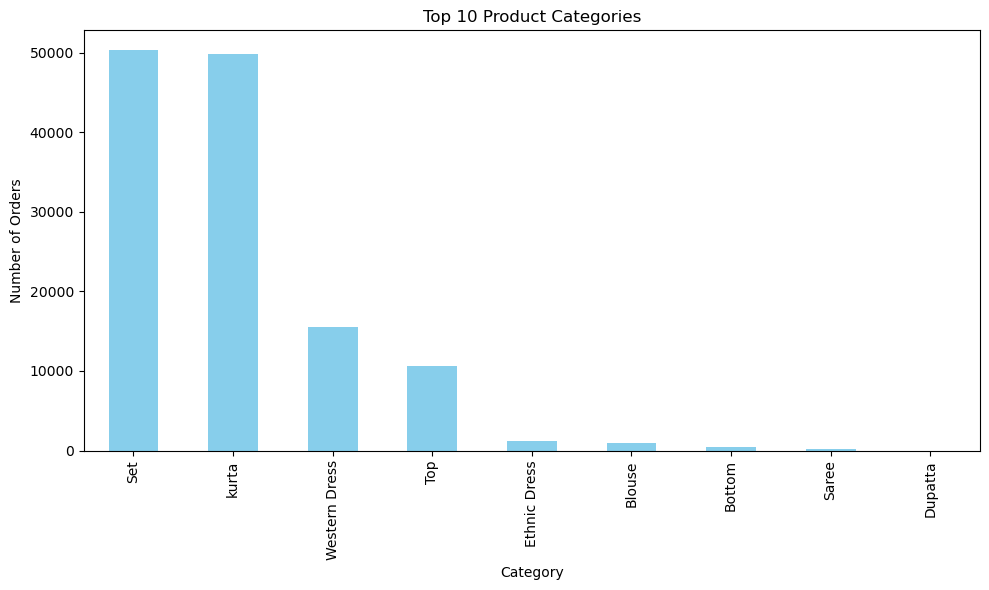

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df["Category"].value_counts().head(10).plot(kind="bar", color="skyblue")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("plots/bar_chart.png")

plt.show()

HISTOGRAM

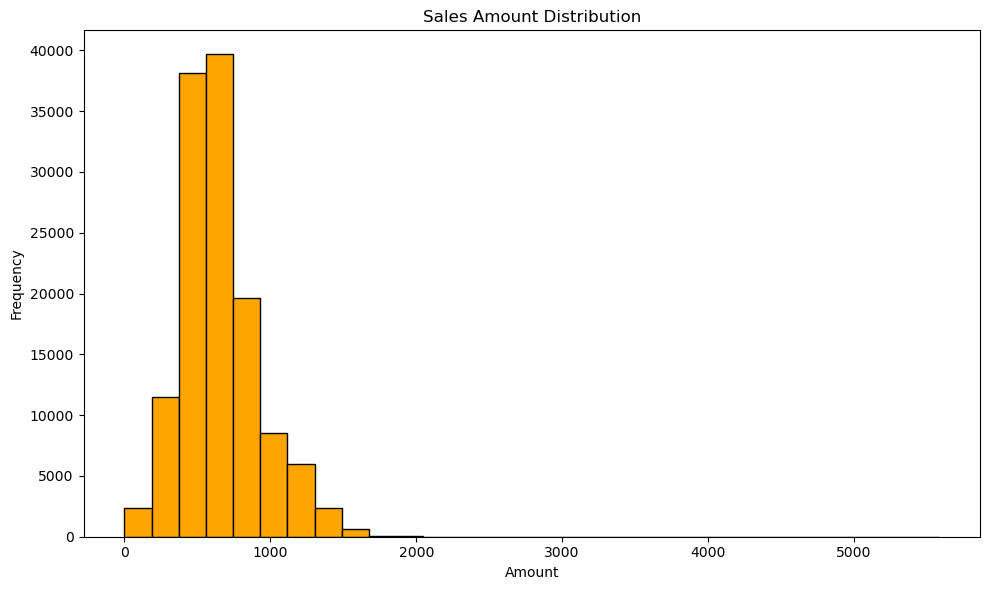

In [17]:
plt.figure(figsize=(10,6))

plt.hist(df["Amount"], bins=30, color="orange", edgecolor="black")

plt.title("Sales Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("plots/histogram.png")

plt.show()

SCATTER PLOT

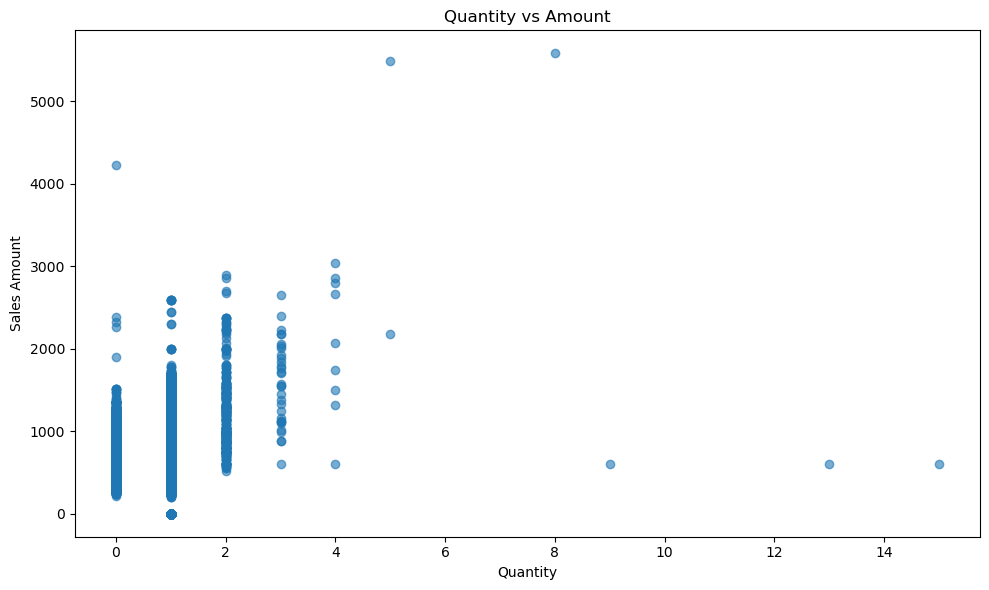

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(df["Qty"], df["Amount"], alpha=0.6)

plt.title("Quantity vs Amount")
plt.xlabel("Quantity")
plt.ylabel("Sales Amount")

plt.tight_layout()
plt.savefig("plots/scatter_plot.png")

plt.show()

HEAT MAP

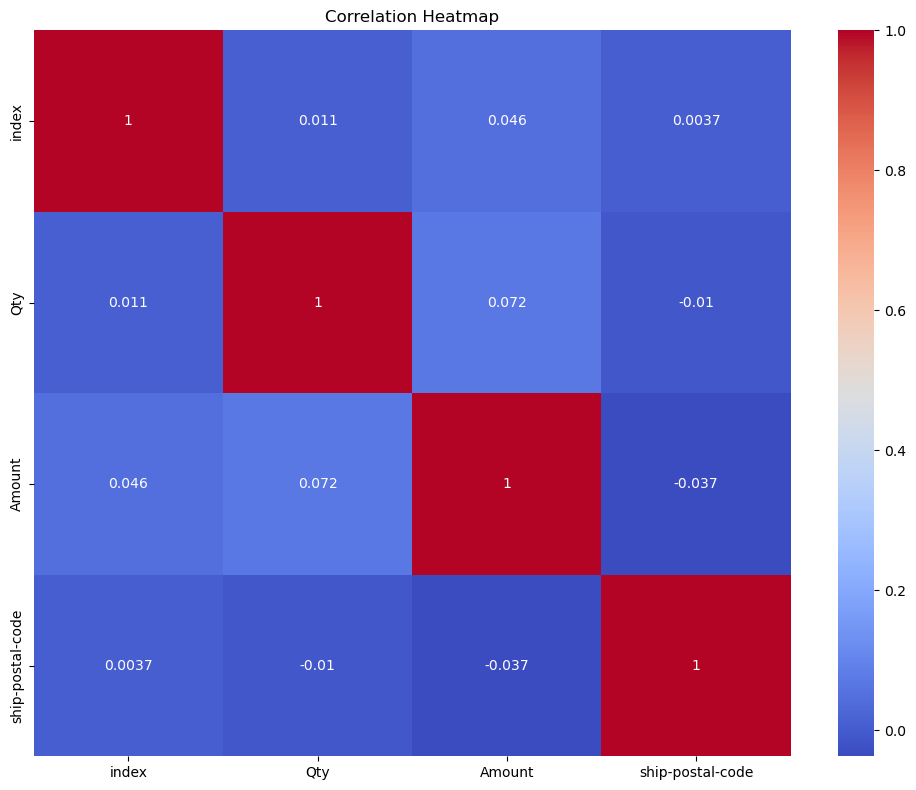

In [19]:
import seaborn as sns

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("plots/heatmap.png")

plt.show()

BOX PLOT

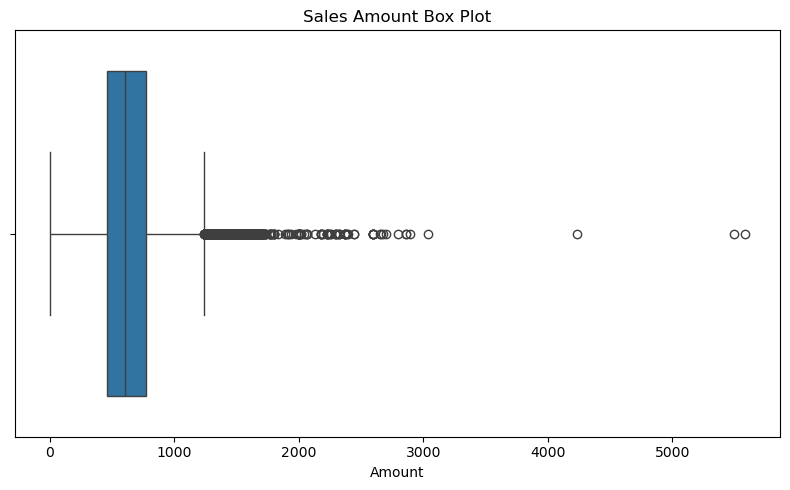

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Amount"])

plt.title("Sales Amount Box Plot")

plt.tight_layout()
plt.savefig("plots/boxplot.png")

plt.show()

PAIR PLOT

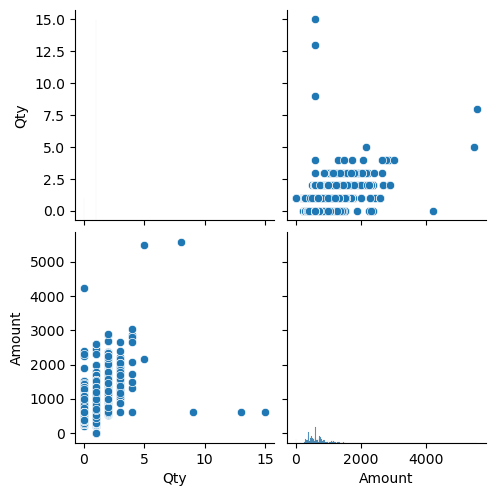

In [21]:
sns.pairplot(df[["Qty","Amount"]])

plt.savefig("plots/pairplot.png")

plt.show()

INTERACTIVE PAIR PLOT

In [22]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Qty",
    y="Amount",
    color="Category",
    title="Interactive Quantity vs Amount"
)

fig.show()

fig.write_html("plots/interactive_plot.html")

DONUT CHART

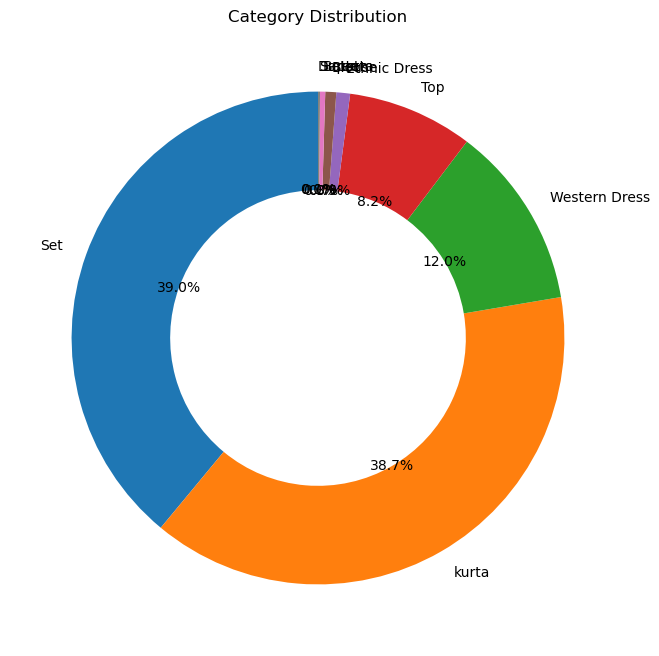

In [23]:
category = df["Category"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    category,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Category Distribution")

plt.savefig("plots/donut_chart.png")

plt.show()